In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display plots inside the notebook
%matplotlib inline
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [22]:

df = pd.read_csv('../data/winequality.csv')  # Make sure the dataset is here
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:

sns.countplot(x='quality', data=df)
plt.title("Wine Quality Count")
plt.show()


In [ ]:

df.hist(bins=15, figsize=(15,10), layout=(4,3))
plt.tight_layout()
plt.show()


In [ ]:
# sns.pairplot(df, hue='quality')  # Uncomment if needed (can be slow)

C:\Users\tyagi\AppData\Local\Temp\ipykernel_9436\3656391324.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_category', data=df, palette='Set2')


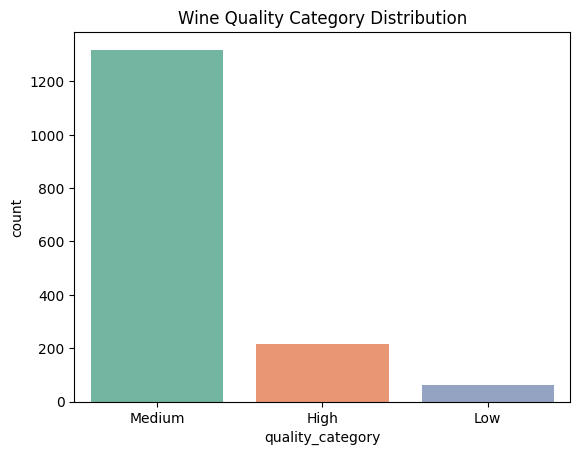

In [23]:
# Mapping quality scores to categories
def quality_category(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(quality_category)

# Check the distribution of the new column
sns.countplot(x='quality_category', data=df, palette='Set2')
plt.title("Wine Quality Category Distribution")
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['quality_label'] = label_encoder.fit_transform(df['quality_category'])

# Let's see how categories got encoded
df[['quality_category', 'quality_label']].drop_duplicates()

,quality_category,quality_label
0,Medium,2
7,High,0
18,Low,1


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features (X) and Label (y)
X = df.drop(['quality', 'quality_category', 'quality_label'], axis=1)
y = df['quality_label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling & Train-Test Split Done!")

Feature Scaling & Train-Test Split Done!


Accuracy: 0.865625

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.57      0.63        47
           1       0.00      0.00      0.00        11
           2       0.89      0.95      0.92       262

    accuracy                           0.87       320
   macro avg       0.53      0.51      0.52       320
weighted avg       0.83      0.87      0.85       320



c:\Users\tyagi\OneDrive\Desktop\wine-quality-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\tyagi\OneDrive\Desktop\wine-quality-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\tyagi\OneDrive\Desktop\wine-quality-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

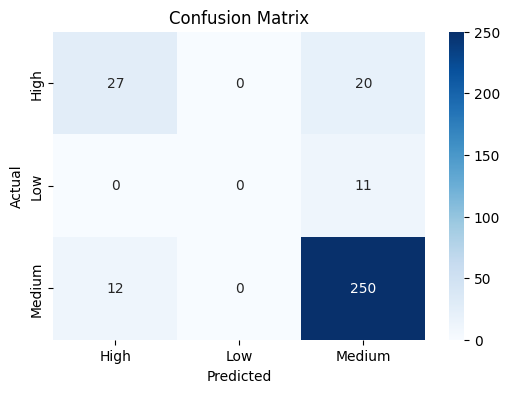

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Model Training
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['High', 'Low', 'Medium'], yticklabels=['High', 'Low', 'Medium'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
import pickle

# Save the trained model
with open('wine_quality_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully as wine_quality_model.pkl")

Model saved successfully as wine_quality_model.pkl


In [28]:
import pickle

# Load the saved model
with open('wine_quality_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Create a sample wine data input (ye ek dummy data hai, real-time input me change kar sakte ho)
sample_input = np.array([[7.4, 0.7, 0, 1.9, 0.076,
                          11, 34, 0.9978, 3.51, 0.56, 9.4]])  # shape (1,11)

# Predict the quality label (0=High, 1=Low, 2=Medium)
predicted_label = loaded_model.predict(sample_input)[0]

# Map back label to category
label_mapping = {0: 'High', 1: 'Low', 2: 'Medium'}
predicted_category = label_mapping[predicted_label]

print(f"Predicted Wine Quality Category: {predicted_category}")

Predicted Wine Quality Category: Medium
